<a href="https://colab.research.google.com/github/heetaamin/ml-assignment2/blob/main/final/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup and Load


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')

from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/MyDrive/Colab Notebooks/Machine Learning/Assignment 2/'

df = pd.read_csv(path + 'networkTraffic.csv', na_values='?')
features = pd.read_csv(path + 'features.csv')

print("Shape:", df.shape)
df.head()

Mounted at /content/drive
Shape: (257673, 44)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat
0,1,0.000011,udp,NaN,INT,2,0,496,0,90909.0902,254,0,180363632.0,0.0,0,0,0.011,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,248,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0,0
1,2,0.000008,udp,NaN,INT,2,0,1762,0,125000.0003,254,0,881000000.0,0.0,0,0,0.008,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,881,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0,0
2,3,0.000005,udp,NaN,INT,2,0,1068,0,200000.0051,254,0,854400000.0,0.0,0,0,0.005,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,534,0,0,0,3,2,1,1,1,3,0,0,0,1,3,0,0
3,4,0.000006,udp,NaN,INT,2,0,900,0,166666.6608,254,0,600000000.0,0.0,0,0,0.006,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,450,0,0,0,3,2,2,2,1,3,0,0,0,2,3,0,0
4,5,0.000010,udp,NaN,INT,2,0,2126,0,100000.0025,254,0,850400000.0,0.0,0,0,0.010,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,1063,0,0,0,3,2,2,2,1,3,0,0,0,2,3,0,0


# Data types and basic structure

In [2]:
print(df.dtypes)
print("\nNumber of unique values per column:")
print(df.nunique().sort_values())

id                     int64
dur                  float64
proto                 object
service               object
state                 object
spkts                  int64
dpkts                  int64
sbytes                 int64
dbytes                 int64
rate                 float64
sttl                   int64
dttl                   int64
sload                float64
dload                float64
sloss                  int64
dloss                  int64
sinpkt               float64
dinpkt               float64
sjit                 float64
djit                 float64
swin                   int64
stcpb                  int64
dtcpb                  int64
dwin                   int64
tcprtt               float64
synack               float64
ackdat               float64
smean                  int64
dmean                  int64
trans_depth            int64
response_body_len      int64
ct_srv_src             int64
ct_state_ttl           int64
ct_dst_ltm             int64
ct_src_dport_l

1. proto, state and service which are given as object types are nominal variables

2. is_ftp_login and is_sm_ips_ports are supposed to be binary variables but is_ftp_login has cardinality of 4 and so this needs some inspection

3. ct_ftp_cmd is a count field but only has 4 unique values and therefore needs investigation

In [3]:
print("is_ftp_login value counts:")
print(df['is_ftp_login'].value_counts(dropna=False))
print()
print("ct_ftp_cmd value counts:")
print(df['ct_ftp_cmd'].value_counts(dropna=False))
print()
print("is_sm_ips_ports value counts:")
print(df['is_sm_ips_ports'].value_counts(dropna=False))

is_ftp_login value counts:
is_ftp_login
0    254428
1      3219
4        16
2        10
Name: count, dtype: int64

ct_ftp_cmd value counts:
ct_ftp_cmd
0    254426
1      3215
2        16
4        16
Name: count, dtype: int64

is_sm_ips_ports value counts:
is_sm_ips_ports
0    253995
1      3678
Name: count, dtype: int64


1. is_ftp_login is documented as binary but has 26 rows (16 + 10) with values of 2 and 4. This is invalid for a binary field. This is a genuine data quality issue to discuss and justify a fix for in the report (likely: treat these as invalid/misencoded and map any non-zero value to 1, since the field is meant to represent "yes/no ftp login occurred").

2. Note - ct_ftp_cmd's distribution is nearly identical to is_ftp_login's (0-254426/254428, 1-3215/3219, and matching small counts at 2/4), which strongly suggests these two columns are highly/perfectly correlated. This is in the assignment but let us confirm it numerically.

In [4]:
print("Correlation:", df['is_ftp_login'].corr(df['ct_ftp_cmd']))
print()
print("Cross-tab:")
print(pd.crosstab(df['is_ftp_login'], df['ct_ftp_cmd']))

Correlation: 0.9988554882935624

Cross-tab:
ct_ftp_cmd         0     1   2   4
is_ftp_login                      
0             254426     2   0   0
1                  0  3213   6   0
2                  0     0  10   0
4                  0     0   0  16


# target variable (attack_cat) distribution.

Missing target values: 0

attack_cat
0    93000
1    13987
2     2329
3    16353
4    44525
5     2677
6    24246
7      174
8     1511
9    58871
Name: count, dtype: int64


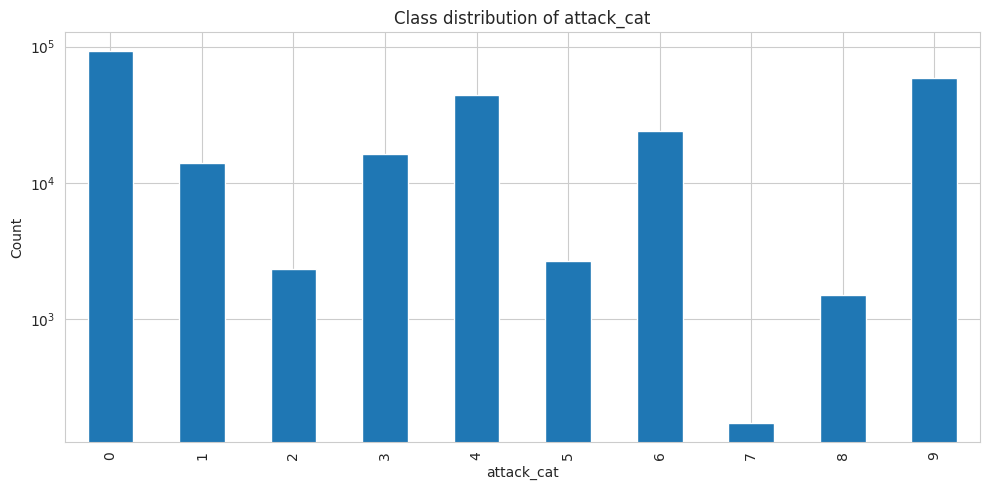

In [5]:
print("Missing target values:", df['attack_cat'].isna().sum())
print()
counts = df['attack_cat'].value_counts(dropna=False).sort_index()
print(counts)

plt.figure(figsize=(10,5))
counts.plot(kind='bar')
plt.title('Class distribution of attack_cat')
plt.ylabel('Count')
plt.xlabel('attack_cat')
plt.yscale('log')
plt.tight_layout()
plt.show()

There is severe class imbalance, class 0 has 93000 instances and class 7 only has 174. This ratio is 535:1

The middle classes from 1-8 are all in the low 1000s to 10,000s.

In terms metrics, plain accuracy would be misleading, predicting only 0 would already get us 36% accuracy for free. Hence use macro-F1, balanced accuracy, or per-class precision/recall/F1 instead.

For the k-fold CV since class 7 only has 174 instances we need to make sure that the fold count does not leave some fold with zero class examples. Stratified cv might be a good option.

# Missing value overview

In [6]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_count', ascending=False)
print(missing_summary)

         missing_count  missing_pct
service         141321        54.85


service is the only column with missing values

# Extra check

In [7]:
print("Count of '-' in state:", (df['state'] == '-').sum())
print()
print("Full state value counts:")
print(df['state'].value_counts(dropna=False))
print()
print("Sum of counts:", df['state'].value_counts(dropna=False).sum(), "vs total rows:", len(df))

Count of '-' in state: 0

Full state value counts:
state
FIN    117164
INT    116438
CON     20134
REQ      3833
RST        84
ECO        12
ACC         4
CLO         1
PAR         1
URN         1
no          1
Name: count, dtype: int64

Sum of counts: 257673 vs total rows: 257673


state has zero missing values and zero '-' placeholders (all 257,673 rows accounted for).
 One invalid category found: 'no' (1 occurrence) - not in the valid state list from features.csv (ACC, CLO, CON, ECO, ECR, FIN, INT, MAS, PAR, REQ, RST, TST, TXD, URH, URN, -).

# mapping target int labels to the categorys


In [8]:
attack_map = pd.read_csv(path + 'attack_category_map.csv')

print(attack_map)

# Build a dictionary
label_map = dict(zip(attack_map['Mapping'], attack_map['Attack Category Name']))
print(label_map)

df['attack_cat_label'] = df['attack_cat'].map(label_map)

print(df[['attack_cat', 'attack_cat_label']].drop_duplicates().sort_values('attack_cat'))

  Attack Category Name  Mapping
0               Normal        0
1       Reconnaissance        1
2             Backdoor        2
3                  DoS        3
4             Exploits        4
5             Analysis        5
6              Fuzzers        6
7                Worms        7
8            Shellcode        8
9              Generic        9
{0: 'Normal', 1: 'Reconnaissance', 2: 'Backdoor', 3: 'DoS', 4: 'Exploits', 5: 'Analysis', 6: 'Fuzzers', 7: 'Worms', 8: 'Shellcode', 9: 'Generic'}
       attack_cat attack_cat_label
0               0           Normal
243             1   Reconnaissance
245             2         Backdoor
246             3              DoS
247             4         Exploits
248             5         Analysis
266             6          Fuzzers
387             7            Worms
425             8        Shellcode
11929           9          Generic


Redoing the target distribution but now with the category names instead of the integer labels

attack_cat_label
Normal            93000
Reconnaissance    13987
Backdoor           2329
DoS               16353
Exploits          44525
Analysis           2677
Fuzzers           24246
Worms               174
Shellcode          1511
Generic           58871
Name: count, dtype: int64


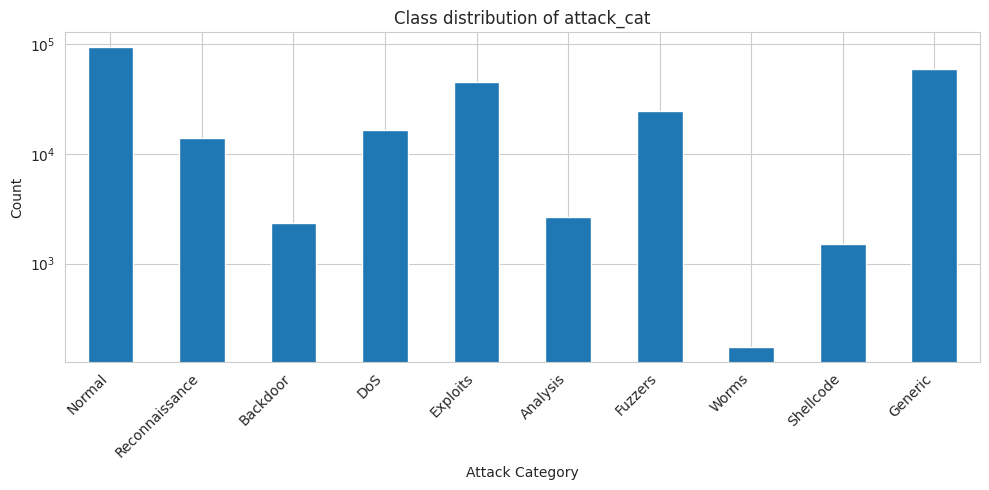

In [9]:
counts = df['attack_cat_label'].value_counts()
# Reorder to match numeric code order for consistency
counts = counts.reindex([label_map[i] for i in sorted(label_map.keys())])

print(counts)

plt.figure(figsize=(10,5))
counts.plot(kind='bar')
plt.title('Class distribution of attack_cat')
plt.ylabel('Count')
plt.xlabel('Attack Category')
plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# categorical/nominal feature exploration

In [10]:
nominal_cols = ['proto', 'state', 'service']

for col in nominal_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False).head(15))
    print(f"Cardinality: {df[col].nunique(dropna=False)}\n")

--- proto ---
proto
tcp       123041
udp        92701
unas       15599
arp         3846
ospf        3271
sctp        1474
any          396
gre          313
rsvp         264
ipv6         262
sun-nd       255
pim          253
mobile       253
swipe        253
sep          251
Name: count, dtype: int64
Cardinality: 133

--- state ---
state
FIN    117164
INT    116438
CON     20134
REQ      3833
RST        84
ECO        12
ACC         4
CLO         1
PAR         1
URN         1
no          1
Name: count, dtype: int64
Cardinality: 11

--- service ---
service
NaN         141321
dns          68661
http         27011
smtp          6909
ftp-data      5391
ftp           4980
pop3          1528
ssh           1506
dhcp           120
snmp           109
ssl             86
irc             30
radius          21
Name: count, dtype: int64
Cardinality: 13



1. proto: 133 unique values but heavily dominated by tcp (123,041) and udp (92,701), together that's about 84% of all rows. The remaining 131 protocol calues form a long tail.

2. service: Excluding the 141,321 missing rows, the observed values are dominated by dns (68,661) and http (27,011), with the rest trailing off. Cardinality is 13 (12 real services + missing).

# Binary/low-cardinality feature sanity + constant columns

In [11]:
binary_like = ['is_ftp_login', 'is_sm_ips_ports']
for col in binary_like:
    print(col, ":", df[col].value_counts(dropna=False))
    print()

const_cols = df.columns[df.nunique(dropna=False) <= 1]
print("Constant (cardinality<=1) columns:", list(const_cols))

is_ftp_login : is_ftp_login
0    254428
1      3219
4        16
2        10
Name: count, dtype: int64

is_sm_ips_ports : is_sm_ips_ports
0    253995
1      3678
Name: count, dtype: int64

Constant (cardinality<=1) columns: []


1. is_ftp_login is documented as binary, but contained 26 invalid rows

2. it is nearly perfect correlated with ct_ftp_cmd - could drop it since it carries near-identical information

3. is_sm_ips_ports: clean binary (0/1 only), no issues.

4. No constant (cardinality<=1) columns found - hence no feature is dropped on this basis

#  Numerical feature summary statistics

In [12]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ['id', 'attack_cat']]  # exclude identifier and target

summary = df[num_cols].describe().T
summary['range'] = summary['max'] - summary['min']
summary

,count,mean,std,min,25%,50%,75%,max,range
dur,257673.0,1.246715e+00,5.974305e+00,0.0,0.000008,0.004285,6.857770e-01,5.999999e+01,5.999999e+01
spkts,257673.0,1.977714e+01,1.359472e+02,1.0,2.000000,4.000000,1.200000e+01,1.064600e+04,1.064500e+04
dpkts,257673.0,1.851470e+01,1.119860e+02,0.0,0.000000,2.000000,1.000000e+01,1.101800e+04,1.101800e+04
sbytes,257673.0,8.572952e+03,1.737739e+05,24.0,114.000000,528.000000,1.362000e+03,1.435577e+07,1.435575e+07
dbytes,257673.0,1.438729e+04,1.461993e+05,0.0,0.000000,178.000000,1.064000e+03,1.465753e+07,1.465753e+07
rate,257673.0,9.125391e+04,1.603446e+05,0.0,30.789277,2955.664893,1.250000e+05,1.000000e+06,1.000000e+06
sttl,257673.0,1.800009e+02,1.024883e+02,0.0,62.000000,254.000000,2.540000e+02,2.550000e+02,2.550000e+02
dttl,257673.0,8.475496e+01,1.127621e+02,0.0,0.000000,29.000000,2.520000e+02,2.540000e+02,2.540000e+02
sload,257673.0,7.060869e+07,1.857313e+08,0.0,12318.004880,743942.312500,8.000000e+07,5.988000e+09,5.988000e+09
dload,257673.0,6.582143e+05,2.412372e+06,0.0,0.000000,1747.441284,2.210538e+04,2.242273e+07,2.242273e+07


 # Outlier detection (IQR method) per numeric feature

In [13]:
outlier_report = []
for col in num_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report.append({'feature': col, 'n_outliers': n_outliers,
                            'pct_outliers': round(n_outliers/len(df)*100, 2)})

outlier_df = pd.DataFrame(outlier_report).sort_values('pct_outliers', ascending=False)
print(outlier_df.to_string(index=False))

          feature  n_outliers  pct_outliers
            dload       57556         22.34
 ct_src_dport_ltm       49014         19.02
 ct_dst_sport_ltm       48244         18.72
   ct_dst_src_ltm       43419         16.85
       ct_dst_ltm       42388         16.45
           dbytes       40024         15.53
            dloss       39660         15.39
            spkts       34871         13.53
       ct_srv_dst       34048         13.21
            dmean       33189         12.88
            smean       32653         12.67
           sbytes       32164         12.48
            dpkts       29737         11.54
             djit       29010         11.26
       ct_src_ltm       28194         10.94
       ct_srv_src       28068         10.89
 ct_flw_http_mthd       25420          9.87
      trans_depth       25422          9.87
             rate       23541          9.14
             sjit       23533          9.13
            sload       22034          8.55
              dur       21597   

# Correlation matrix

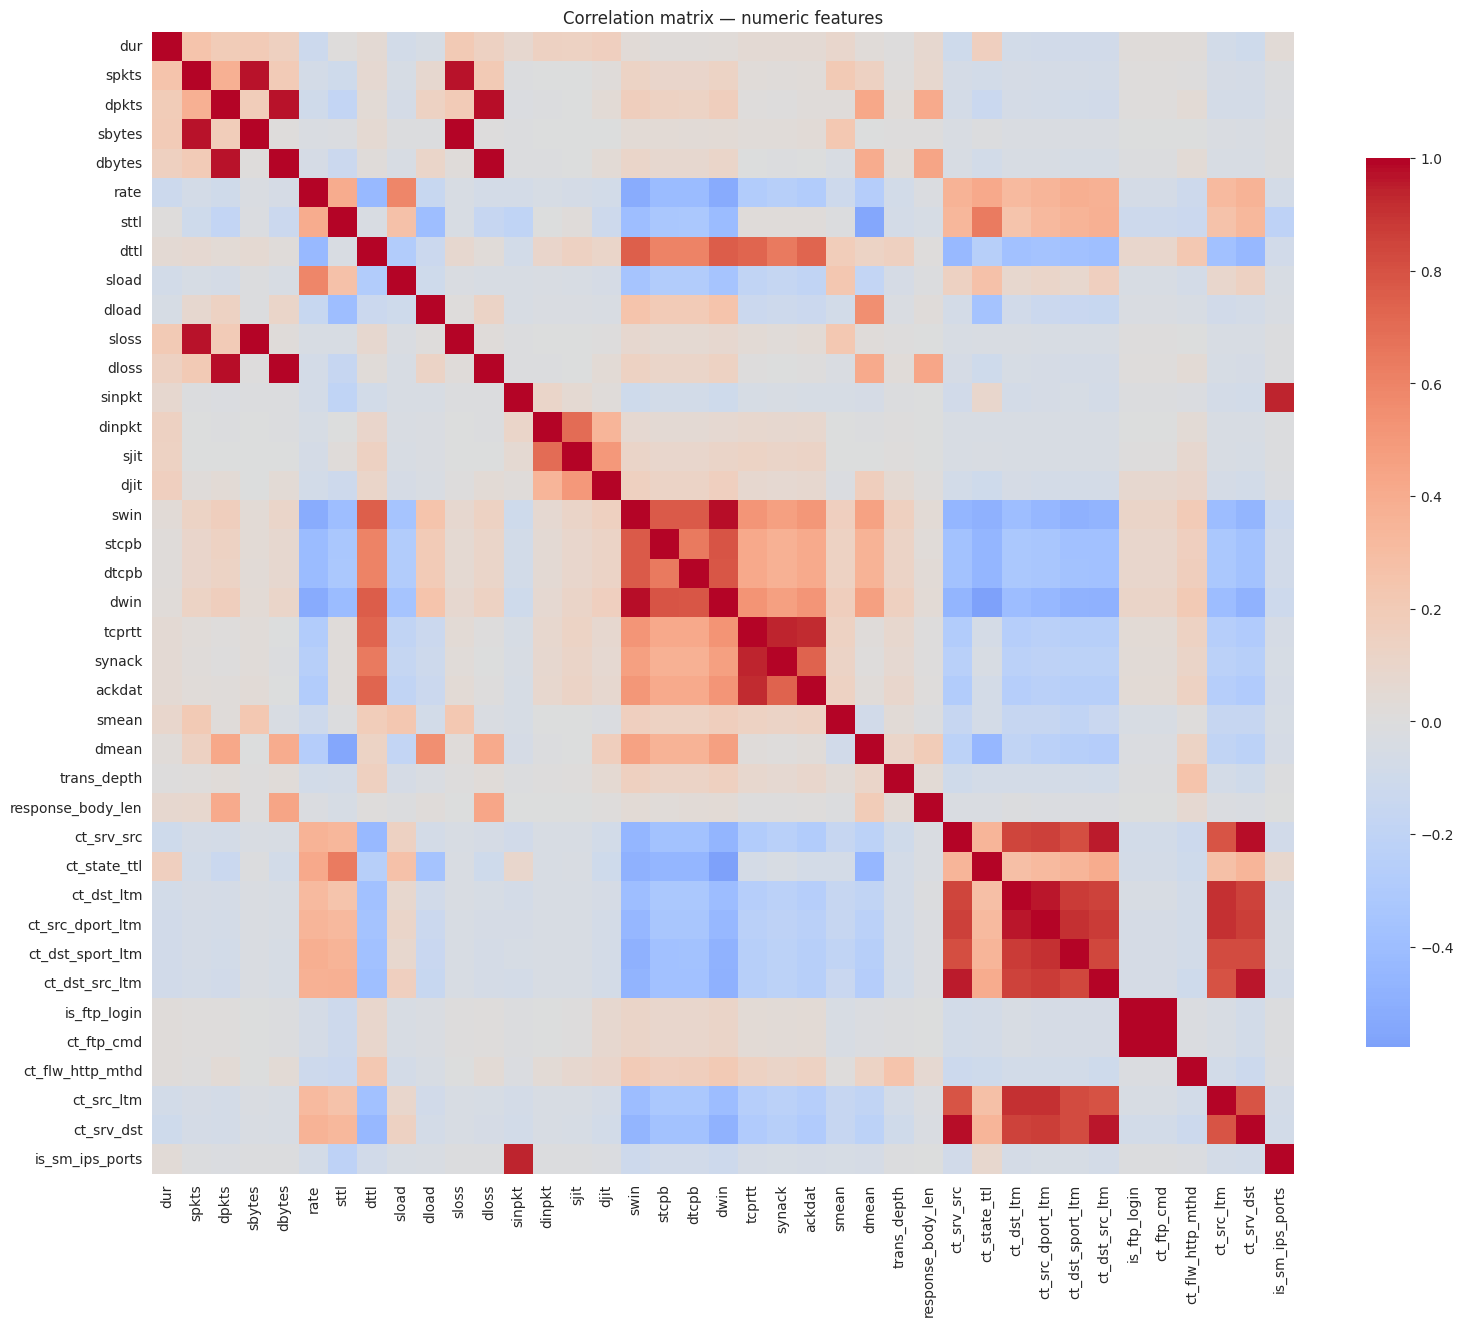

ct_ftp_cmd        is_ftp_login        0.998855
dloss             dbytes              0.996711
sbytes            sloss               0.995772
swin              dwin                0.980458
dpkts             dloss               0.979612
ct_srv_src        ct_srv_dst          0.979467
dpkts             dbytes              0.973445
spkts             sloss               0.971859
                  sbytes              0.964393
ct_src_dport_ltm  ct_dst_ltm          0.961518
ct_dst_src_ltm    ct_srv_dst          0.960321
ct_srv_src        ct_dst_src_ltm      0.953952
tcprtt            synack              0.943053
sinpkt            is_sm_ips_ports     0.942121
tcprtt            ackdat              0.920218
ct_src_ltm        ct_src_dport_ltm    0.909430
ct_dst_sport_ltm  ct_src_dport_ltm    0.908337
ct_src_ltm        ct_dst_ltm          0.901582
dtype: float64


In [14]:
corr = df[num_cols].corr()

plt.figure(figsize=(16,14))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True, cbar_kws={'shrink':0.7})
plt.title('Correlation matrix — numeric features')
plt.tight_layout()
plt.show()

# Flag strongly correlated pairs (|r| > 0.9)
corr_pairs = corr.abs().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1.0]  # remove self-correlation
strong_pairs = corr_pairs[corr_pairs > 0.9].drop_duplicates()
print(strong_pairs)

The correlation analysis confirms all three explicitly documented issues from the assignment brief (is_ftp_login/ct_ftp_cmd, dbytes/dloss, sbytes/sloss) plus roughly 15 additional strong correlations (|r| > 0.9) not explicitly named but implied by the brief's "many other very strong correlations" statement. These cluster into three logical families: connection-count features (ct_*), byte/packet volume pairs, and the TCP timing triad (tcprtt = synack + ackdat by definition).

Checking the correlation between is_sm_ips_ports and sinkpt

In [15]:
print(df.groupby('is_sm_ips_ports')['sinpkt'].describe())

                    count          mean           std  min        25%  \
is_sm_ips_ports                                                         
0                253995.0    127.534876   1248.547713  0.0      0.008   
1                  3678.0  55106.599264  16424.549238  0.0  60000.632   

                          50%           75%        max  
is_sm_ips_ports                                         
0                    0.331957     55.139207  84371.496  
1                60000.696000  60000.744000  60009.992  


this correlation is not a meaningful redundancy in the way sbytes/sloss is, but rather reflects a near-constant value artifact within a small subgroup of the data (is_sm_ips_ports=1) and should not be treated the same way in preprocessing decisions (e.g., don't drop sinpkt or is_sm_ips_ports on the assumption they're redundant — they capture different information despite the high correlation coefficient).

# Explicit check of specific known correlated pairs

In [16]:
pairs_to_check = [
    ('sbytes', 'sloss'), ('dbytes', 'dloss'),
    ('is_ftp_login', 'ct_ftp_cmd'), ('tcprtt', 'synack'), ('tcprtt', 'ackdat')
]
for a, b in pairs_to_check:
    if a in df.columns and b in df.columns:
        print(f"{a} vs {b}: r = {df[a].corr(df[b]):.4f}")

sbytes vs sloss: r = 0.9958
dbytes vs dloss: r = 0.9967
is_ftp_login vs ct_ftp_cmd: r = 0.9989
tcprtt vs synack: r = 0.9431
tcprtt vs ackdat: r = 0.9202


# Numeric feature scale comparison

In [17]:
scale_check = df[num_cols].agg(['min','max']).T
scale_check['order_of_magnitude'] = np.log10(scale_check['max'].replace(0, np.nan).abs())
scale_check.sort_values('order_of_magnitude', ascending=False)

,min,max,order_of_magnitude
sload,0.0,5.988000e+09,9.777282
stcpb,0.0,4.294959e+09,9.632959
dtcpb,0.0,4.294882e+09,9.632951
dload,0.0,2.242273e+07,7.350688
dbytes,0.0,1.465753e+07,7.166061
sbytes,24.0,1.435577e+07,7.157027
response_body_len,0.0,6.558056e+06,6.816775
sjit,0.0,1.483831e+06,6.171384
rate,0.0,1.000000e+06,6.000000
djit,0.0,4.631992e+05,5.665768


# id uniqueness and duplicate row check

In [18]:
print("id unique:", df['id'].nunique(), "of", len(df), "-> all unique:", df['id'].nunique() == len(df))
print()
print("Fully duplicate rows (all columns identical):", df.duplicated().sum())
print("Duplicate rows excluding id:", df.drop(columns='id').duplicated().sum())

id unique: 257673 of 257673 -> all unique: True

Fully duplicate rows (all columns identical): 0
Duplicate rows excluding id: 94928


# Check whether duplication is concentrated in certain attack categories

In [19]:
dup_mask = df.drop(columns='id').duplicated(keep=False)  # keep=False flags ALL rows involved in a duplicate group, not just repeats
print("Total rows involved in duplication:", dup_mask.sum())
print()
print("Attack category distribution among duplicated rows:")
print(df[dup_mask]['attack_cat_label'].value_counts())
print()
print("Attack category distribution among non-duplicated rows:")
print(df[~dup_mask]['attack_cat_label'].value_counts())

Total rows involved in duplication: 113828

Attack category distribution among duplicated rows:
attack_cat_label
Generic           56799
Exploits          21365
DoS               12673
Normal            10832
Fuzzers            5199
Reconnaissance     4930
Analysis           1111
Backdoor            814
Shellcode            99
Worms                 6
Name: count, dtype: int64

Attack category distribution among non-duplicated rows:
attack_cat_label
Normal            82168
Exploits          23160
Fuzzers           19047
Reconnaissance     9057
DoS                3680
Generic            2072
Analysis           1566
Backdoor           1515
Shellcode          1412
Worms               168
Name: count, dtype: int64


Duplication varies greatly across attack categories. Generic (96.5%) and DoS (77.5%) contain mostly duplicated rows, while Worms (3.4%) and Shellcode (7.0%) contain very little duplication. This suggests that some of the class imbalance seen in Cell 3 may be caused by duplication rather than true class frequencies. However, it is unclear whether these duplicates are a data quality issue that should be removed or whether they represent genuine patterns in network traffic. This decision should therefore be considered carefully, as deduplication could affect both the class distribution and the risk of train/test leakage during k-fold cross-validation.


# Formal Data Quality Report tables


In [20]:
# Continuous descriptive features

df_calc = df.replace('?', np.nan)
n_total = len(df_calc)

continuous_cols = [
    'id','dur','spkts','dpkts','sbytes','dbytes','rate','sttl','dttl','sload',
    'dload','sloss','dloss','sinpkt','dinpkt','sjit','djit','swin','stcpb',
    'dtcpb','dwin','tcprtt','synack','ackdat','smean','dmean','trans_depth',
    'response_body_len','ct_srv_src','ct_state_ttl','ct_dst_ltm',
    'ct_src_dport_ltm','ct_dst_sport_ltm','ct_dst_src_ltm','ct_ftp_cmd',
    'ct_flw_http_mthd','ct_src_ltm','ct_srv_dst'
]
assert len(continuous_cols) == 38, f"Expected 38, got {len(continuous_cols)}"

continuous_rows = []
for col in continuous_cols:
    series = pd.to_numeric(df_calc[col], errors='coerce')
    count = series.notna().sum()
    pct_miss = (n_total - count) / n_total * 100
    continuous_rows.append({
        'Feature': col, 'Count': count, '% Miss.': round(pct_miss, 2),
        'Card.': series.nunique(), 'Min.': round(series.min(), 3),
        '1st Qrt.': round(series.quantile(0.25), 3), 'Mean': round(series.mean(), 3),
        'Median': round(series.median(), 3), '3rd Qrt.': round(series.quantile(0.75), 3),
        'Max.': round(series.max(), 3), 'Std. Dev.': round(series.std(), 3),
    })

continuous_dqr = pd.DataFrame(continuous_rows)
continuous_dqr.to_csv('/content/drive/MyDrive/Colab Notebooks/Machine Learning/Assignment 2/continuous_DQR.csv', index=False)
print(continuous_dqr.to_string())

              Feature   Count  % Miss.   Card.  Min.   1st Qrt.          Mean      Median      3rd Qrt.          Max.     Std. Dev.
0                  id  257673      0.0  257673   1.0  64419.000  1.288370e+05  128837.000  1.932550e+05  2.576730e+05  7.438393e+04
1                 dur  257673      0.0  109945   0.0      0.000  1.247000e+00       0.004  6.860000e-01  6.000000e+01  5.974000e+00
2               spkts  257673      0.0     646   1.0      2.000  1.977700e+01       4.000  1.200000e+01  1.064600e+04  1.359470e+02
3               dpkts  257673      0.0     627   0.0      0.000  1.851500e+01       2.000  1.000000e+01  1.101800e+04  1.119860e+02
4              sbytes  257673      0.0    9382  24.0    114.000  8.572952e+03     528.000  1.362000e+03  1.435577e+07  1.737739e+05
5              dbytes  257673      0.0    8653   0.0      0.000  1.438729e+04     178.000  1.064000e+03  1.465753e+07  1.461993e+05
6                rate  257673      0.0  115763   0.0     30.789  9.125391e+0

In [21]:
# Categorical descriptive features

categorical_cols = ['proto', 'state', 'service', 'is_ftp_login', 'is_sm_ips_ports']
assert len(categorical_cols) == 5

categorical_rows = []
for col in categorical_cols:
    series = df_calc[col]
    count = series.notna().sum()
    pct_miss = (n_total - count) / n_total * 100
    card = series.nunique()
    vc = series.value_counts()
    mode_val, mode_freq = vc.index[0], vc.iloc[0]
    mode_pct = mode_freq / count * 100
    if len(vc) > 1:
        mode2_val, mode2_freq = vc.index[1], vc.iloc[1]
        mode2_pct = mode2_freq / count * 100
    else:
        mode2_val, mode2_freq, mode2_pct = None, 0, 0.0
    categorical_rows.append({
        'Feature': col, 'Count': count, '% Miss.': round(pct_miss, 2), 'Card.': card,
        'Mode': mode_val, 'Mode Freq.': mode_freq, 'Mode %': round(mode_pct, 2),
        '2nd Mode': mode2_val, '2nd Mode Freq.': mode2_freq, '2nd Mode %': round(mode2_pct, 2),
    })

categorical_dqr = pd.DataFrame(categorical_rows)
categorical_dqr.to_csv('/content/drive/MyDrive/Colab Notebooks/Machine Learning/Assignment 2/categorical_DQR.csv', index=False)
print(categorical_dqr.to_string())

           Feature   Count  % Miss.  Card. Mode  Mode Freq.  Mode % 2nd Mode  2nd Mode Freq.  2nd Mode %
0            proto  257673     0.00    133  tcp      123041   47.75      udp           92701       35.98
1            state  257673     0.00     11  FIN      117164   45.47      INT          116438       45.19
2          service  116352    54.85     12  dns       68661   59.01     http           27011       23.21
3     is_ftp_login  257673     0.00      4    0      254428   98.74        1            3219        1.25
4  is_sm_ips_ports  257673     0.00      2    0      253995   98.57        1            3678        1.43


In [22]:
# Target feature

target_col = 'attack_cat'
series = df_calc[target_col]
count = series.notna().sum()
pct_miss = (n_total - count) / n_total * 100
card = series.nunique()
vc = series.value_counts()
mode_val, mode_freq = vc.index[0], vc.iloc[0]
mode_pct = mode_freq / count * 100
mode2_val, mode2_freq = vc.index[1], vc.iloc[1]
mode2_pct = mode2_freq / count * 100

target_dqr = pd.DataFrame([{
    'Feature': target_col, 'Count': count, '% Miss.': round(pct_miss, 2), 'Card.': card,
    'Mode': mode_val, 'Mode Freq.': mode_freq, 'Mode %': round(mode_pct, 2),
    '2nd Mode': mode2_val, '2nd Mode Freq.': mode2_freq, '2nd Mode %': round(mode2_pct, 2),
}])
target_dqr.to_csv('/content/drive/MyDrive/Colab Notebooks/Machine Learning/Assignment 2/target_DQR.csv', index=False)
print(target_dqr.to_string())

      Feature   Count  % Miss.  Card.  Mode  Mode Freq.  Mode %  2nd Mode  2nd Mode Freq.  2nd Mode %
0  attack_cat  257673      0.0     10     0       93000   36.09         9           58871       22.85


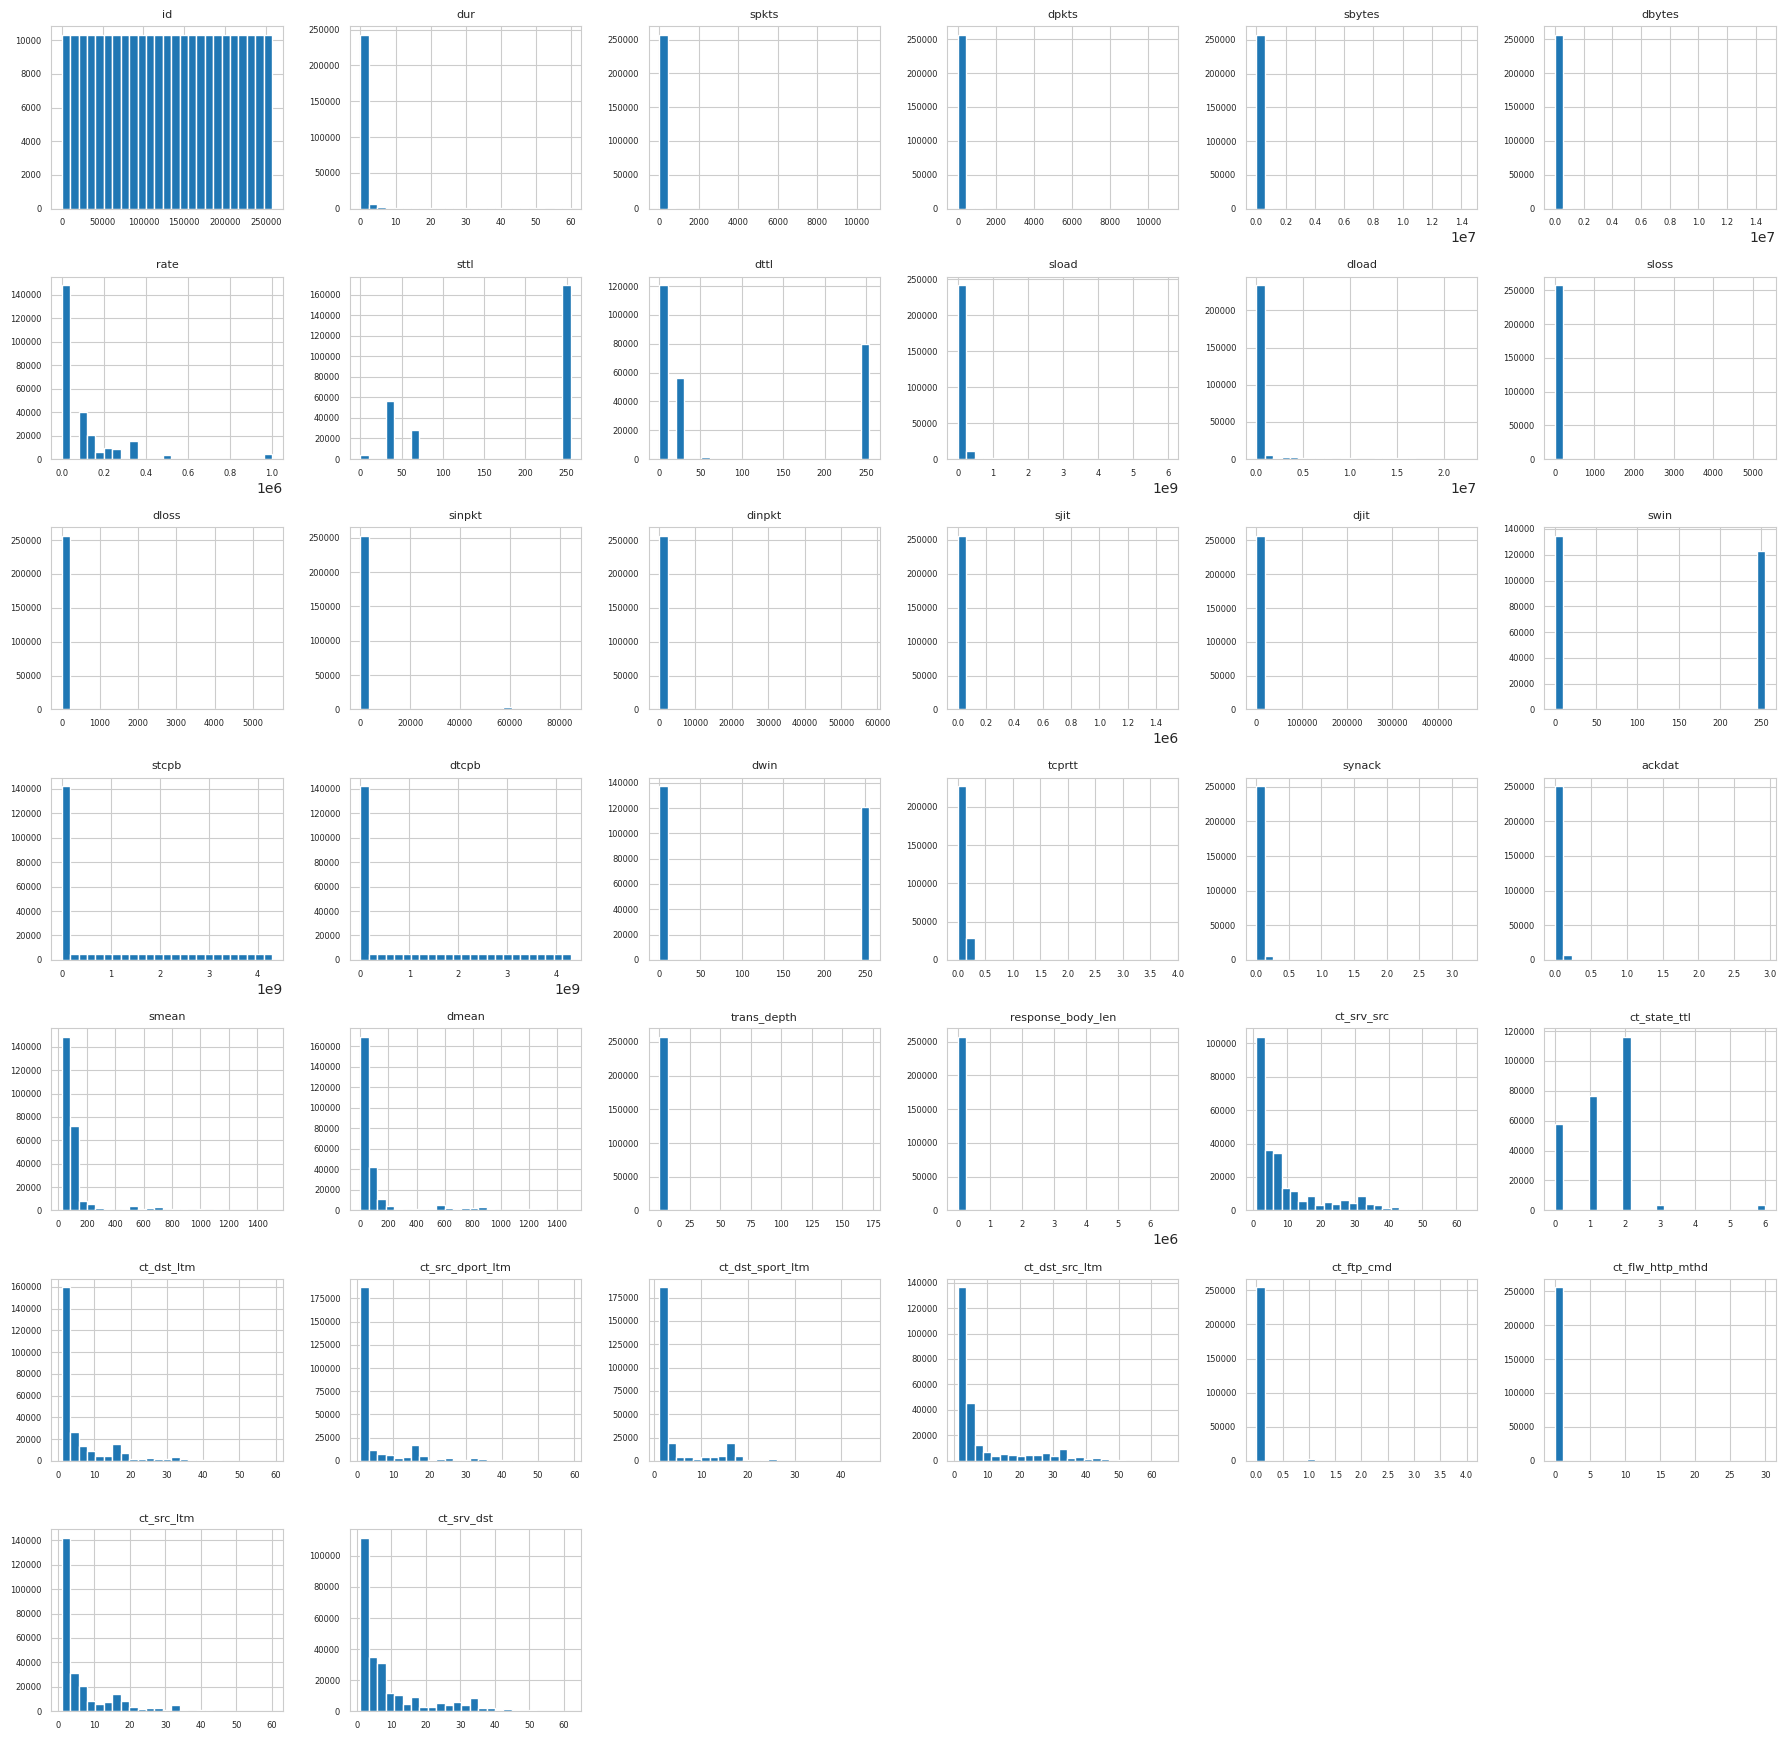

In [23]:
#  Histograms for all 38 continuous descriptive

import matplotlib.pyplot as plt

n_cols = 6
n_rows = -(-len(continuous_cols) // n_cols)  # ceiling division -> 7 rows for 38
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 2.5))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    axes[i].hist(pd.to_numeric(df_calc[col], errors='coerce'), bins=25)
    axes[i].set_title(col, fontsize=8)
    axes[i].tick_params(axis='both', labelsize=6)

for i in range(len(continuous_cols), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/Machine Learning/Assignment 2/continuous_histograms.pdf')
plt.show()

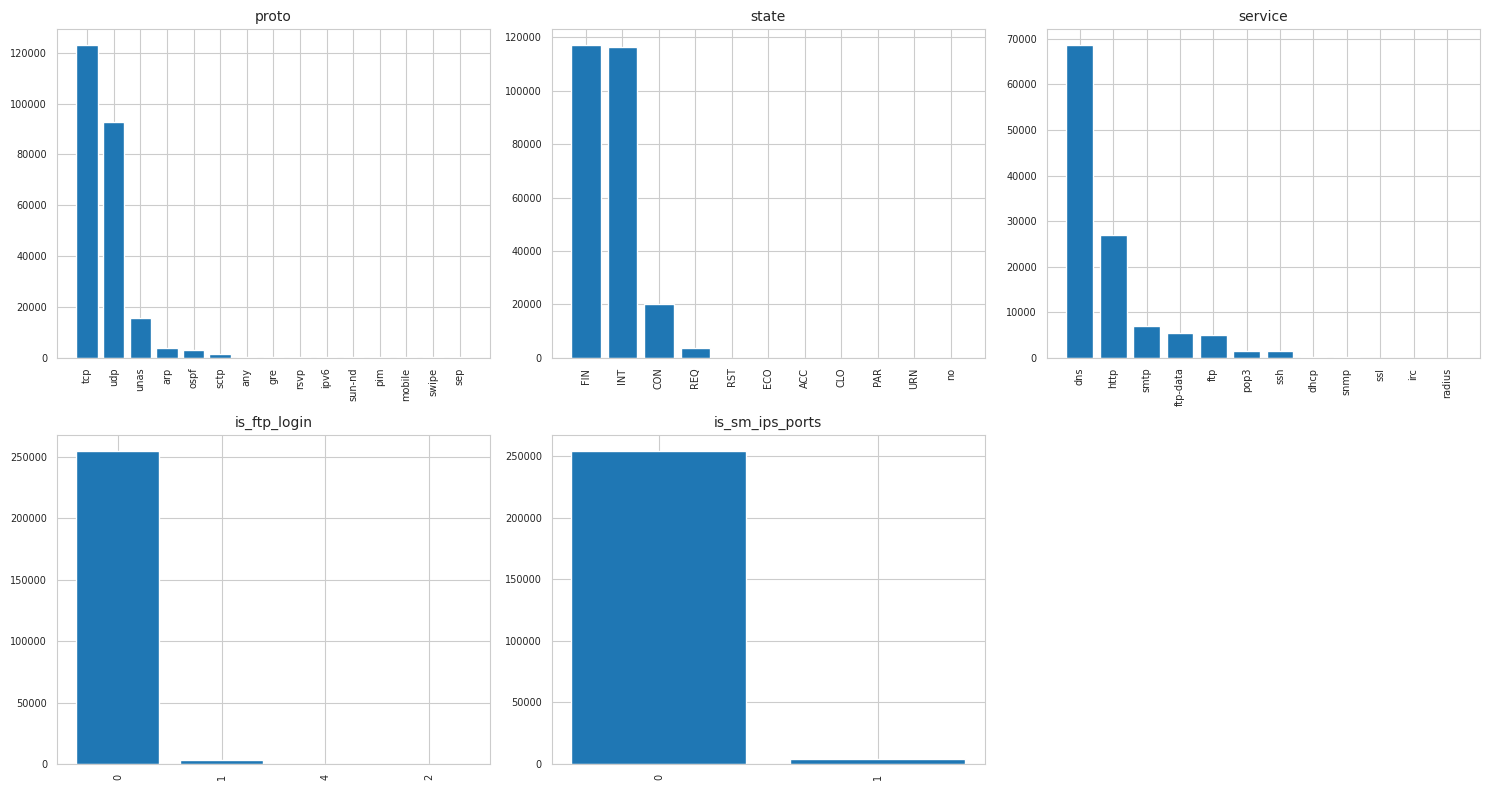

In [24]:
# Bar plots for all 5 categorical descriptive

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    top_categories = df_calc[col].value_counts().head(15)
    axes[i].bar(top_categories.index.astype(str), top_categories.values)
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis='x', rotation=90, labelsize=7)
    axes[i].tick_params(axis='y', labelsize=7)

for i in range(len(categorical_cols), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/Machine Learning/Assignment 2/categorical_barplots.pdf')
plt.show()

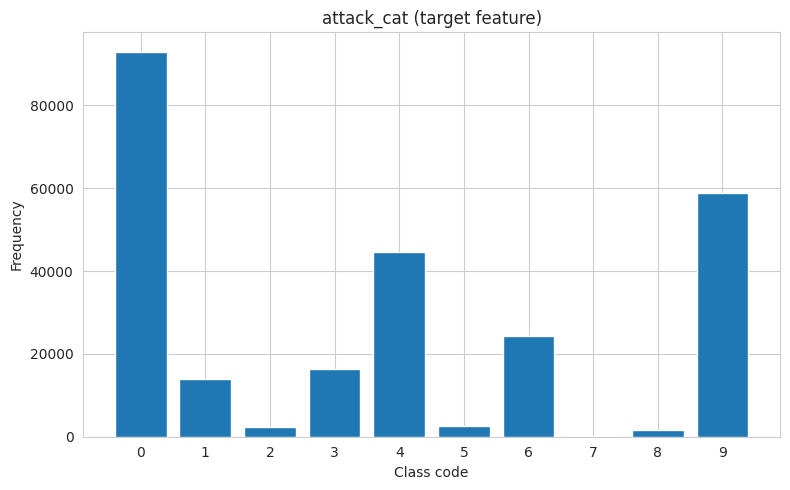

In [25]:
# Target feature

fig, ax = plt.subplots(figsize=(8, 5))
target_counts = df_calc['attack_cat'].value_counts().sort_index()
ax.bar(target_counts.index.astype(str), target_counts.values)
ax.set_title('attack_cat (target feature)', fontsize=12)
ax.set_xlabel('Class code')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/Machine Learning/Assignment 2/target_barplot.pdf')
plt.show()

# Check whether infrequent protocols can be safely grouped into "other" without losing information

In [27]:
pd.crosstab(df['proto'], df['attack_cat'], normalize='index').round(3) * 100

# check the specific protocols the report claims
target_protos = ['arp', 'udp', 'any', 'gre', 'ipv6', 'rsvp', 'sctp']
crosstab_full = pd.crosstab(df['proto'], df['attack_cat'], normalize='index').round(3) * 100
crosstab_full.loc[crosstab_full.index.isin(target_protos)]

attack_cat,0,1,2,3,4,5,6,7,8,9
proto,,,,,,,,,,
any,0.0,5.3,5.3,33.3,41.7,6.1,7.6,0.0,0.0,0.8
arp,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
gre,0.0,6.1,4.8,34.2,43.8,4.5,5.8,0.0,0.0,1.0
ipv6,0.0,5.3,4.6,32.1,46.9,3.4,6.1,0.0,0.0,1.5
rsvp,0.0,5.3,5.3,33.3,41.7,6.1,7.6,0.0,0.0,0.8
sctp,0.0,7.7,4.7,28.9,50.1,1.8,5.2,0.0,0.0,1.7
udp,23.8,5.3,0.0,0.6,0.9,0.0,6.5,0.0,0.8,62.1
